In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
from tailnflows.utils import get_project_root, load_raw_data, load_experiment_output_data

In [3]:
losses = load_experiment_output_data('2026-08-04-synth-de')

In [4]:
losses

{'normal': [{'dim': 10,
   'repeat': 0,
   'seed': 2,
   'tst_ll': 2.2406933718551757e+17,
   'df': 0.5},
  {'dim': 10, 'repeat': 0, 'seed': 2, 'tst_ll': 19.502294540405273, 'df': 2.0},
  {'dim': 10,
   'repeat': 1,
   'seed': 2,
   'tst_ll': 1.8090301319020544e+16,
   'df': 0.5},
  {'dim': 10, 'repeat': 1, 'seed': 2, 'tst_ll': 19.715091705322266, 'df': 2.0},
  {'dim': 10,
   'repeat': 2,
   'seed': 2,
   'tst_ll': 2.1408187339678637e+22,
   'df': 0.5},
  {'dim': 10, 'repeat': 2, 'seed': 2, 'tst_ll': 19.709810256958008, 'df': 2.0},
  {'dim': 10, 'repeat': 3, 'seed': 2, 'tst_ll': 7388035238854656.0, 'df': 0.5},
  {'dim': 10, 'repeat': 3, 'seed': 2, 'tst_ll': 19.35425567626953, 'df': 2.0},
  {'dim': 10, 'repeat': 4, 'seed': 2, 'tst_ll': 2356670298587136.0, 'df': 0.5},
  {'dim': 10, 'repeat': 4, 'seed': 2, 'tst_ll': 20.67021942138672, 'df': 2.0}],
 'g_normal': [{'dim': 10,
   'repeat': 0,
   'seed': 2,
   'tst_ll': 339284028555264.0,
   'df': 0.5},
  {'dim': 10, 'repeat': 0, 'seed': 2, 't

In [5]:
raw_data = load_experiment_output_data('2026-08-04-synth-de')
rows = []
for label, _data in raw_data.items():
    # if label != 'comet':
    for experiment_outcome in _data:
        rows.append({
            'model': label,
            'tst_negll_per_dim': experiment_outcome['tst_ll'] / experiment_outcome['dim'],
            'df': experiment_outcome['df'],
            'dim': experiment_outcome['dim']
        })


# raw_data = load_raw_data('alt_shift_de_2023_12_01')
# for test_ll, dim, df in raw_data['comet']:
#     rows.append({
#         'model': 'comet',
#         'tst_negll_per_dim': test_ll / dim,
#         'df': df,
#         'dim': dim
#     })

In [8]:
len(raw_data['gtaf'])

10

In [9]:
raw_data.keys()

dict_keys(['normal', 'g_normal', 'ttf_m', 'ttf_m_fix', 'mtaf', 'gtaf', 'm_normal', 'comet'])

In [10]:
results = pd.DataFrame(rows)
# results = results[~results.isin([np.nan, np.inf, -np.inf]).any(1)]


In [11]:
results.groupby(['model', 'df', 'dim']).count()

tst_negll_per_dim
model     df  dim                   
comet     0.5 10                   5
          2.0 10                   5
g_normal  0.5 10                   5
          2.0 10                   5
gtaf      0.5 10                   5
          2.0 10                   5
m_normal  0.5 10                   5
          2.0 10                   5
mtaf      0.5 10                   5
          2.0 10                   5
normal    0.5 10                   5
          2.0 10                   5
ttf_m     0.5 10                   5
          2.0 10                   5
ttf_m_fix 0.5 10                   5
          2.0 10                   5

### Box Plots

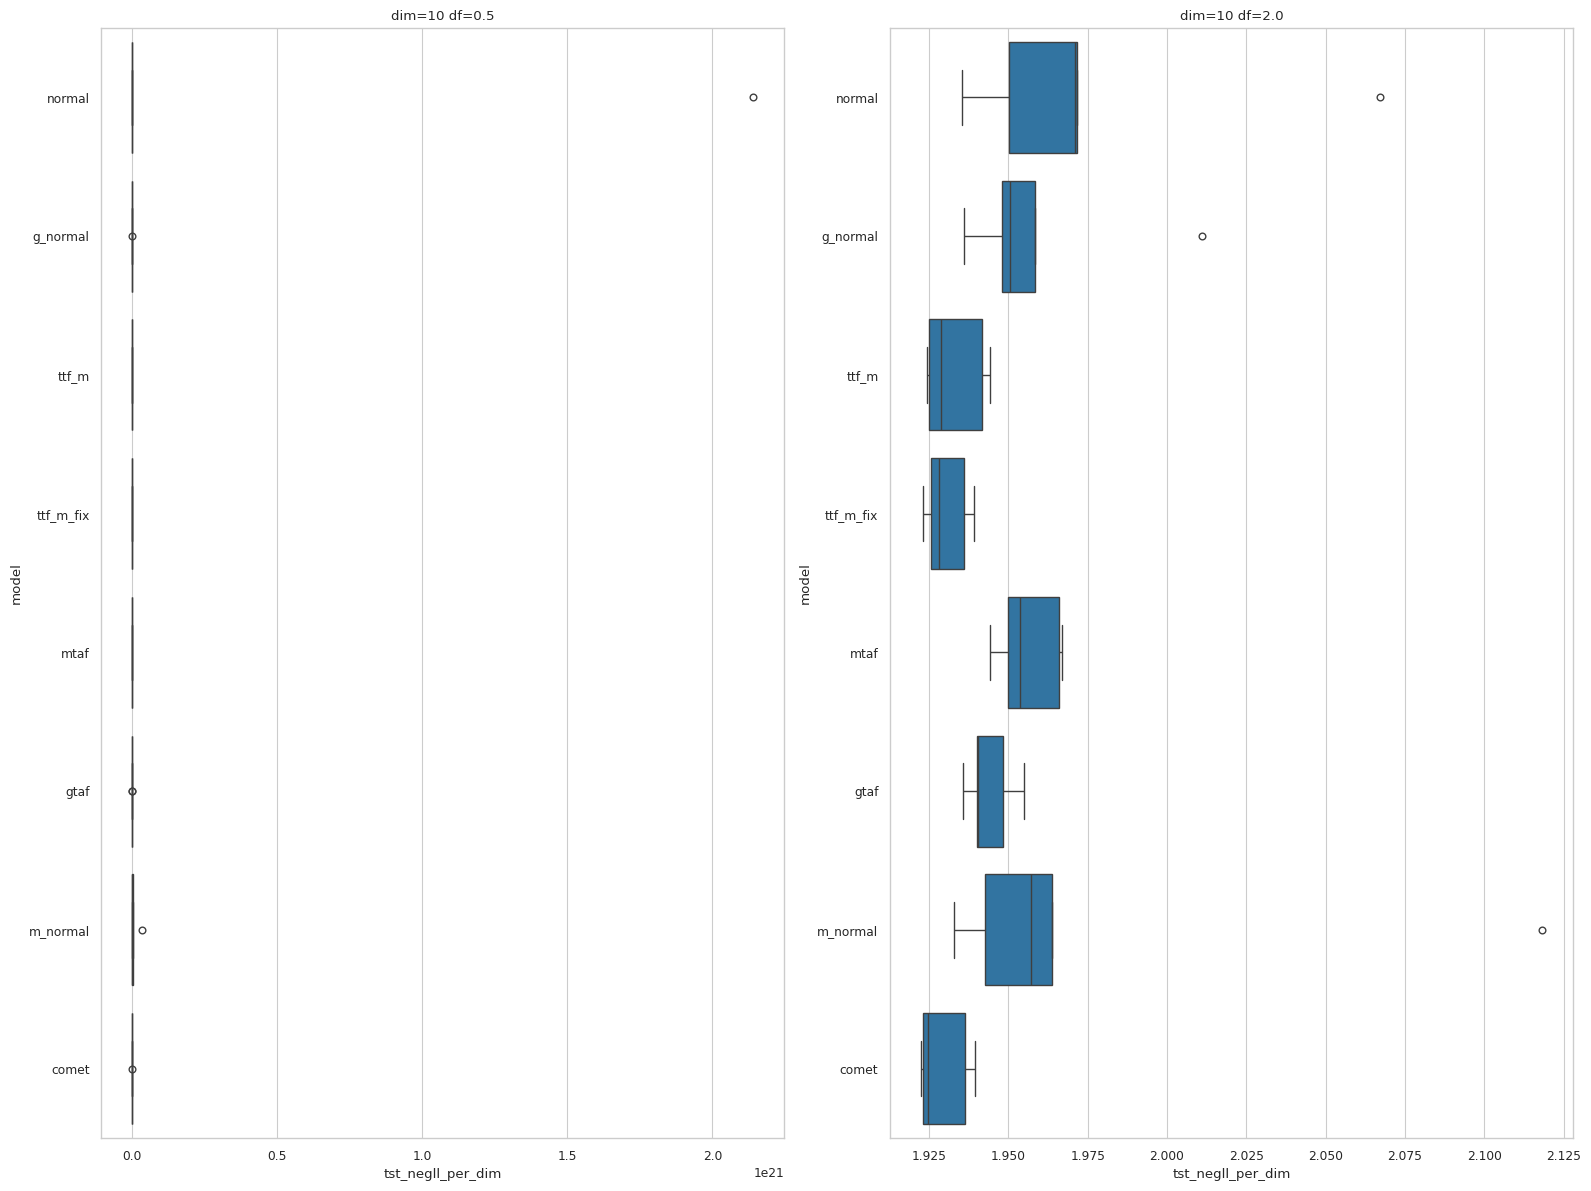

In [13]:
import seaborn as sns

wanted_dims = sorted(results['dim'].unique())
wanted_dfs = sorted(results['df'].unique())
wanted_models = results.model.unique()

fig, axarr = plt.subplots(len(wanted_dims), len(wanted_dfs), figsize=(16, 12), tight_layout=True)

# if len(wanted_dims) == 1 and len(wanted_dfs) == 1:
#   axarr = [[axarr]]

# Ensure axarr is always a 2D array
if len(wanted_dims) == 1:
    axarr = axarr[np.newaxis, :]
if len(wanted_dfs) == 1:
    axarr = axarr[:, np.newaxis]

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.)

for i, dim in enumerate(wanted_dims):
  for j, nuisance_df in enumerate(wanted_dfs):
    wanted_data = results[np.logical_and(
        results['dim'] == dim,
        results['df'] == nuisance_df,
    )]

    sns.boxplot(
        data=wanted_data,
        x='tst_negll_per_dim',
        y='model',
        order=wanted_models,
        orient='h',
        ax=axarr[i][j],
    )

    axarr[i][j].set_title(f'dim={dim} df={nuisance_df:.1f}')

    # if j == 0:
      # axarr[i][j].set_xlim([0., 2.3])

In [ ]:
agg = results.groupby(['dim', 'df', 'model'], group_keys=False).agg(['mean', 'sem'])

# 'sem' = 'Standard Error of the Mean' -> Measures the spread of a bunch of samples, like std

unpacked_rows = []
for (dim, df, model), test_neg_ll_agg in agg.iterrows():
    unpacked_rows.append(
        {
            'model': model,
            'df': df,
            'dim': dim,
            'tst_negll': test_neg_ll_agg.values[0],
            'sem': test_neg_ll_agg.values[1],
        }
    )

rezzas = pd.DataFrame(unpacked_rows)
rezzas

,model,df,dim,tst_negll,sem
0,comet,0.5,10,3.619475e+00,1.218962e-02
1,g_normal,0.5,10,1.367155e+17,1.364764e+17
2,gtaf,0.5,10,8.644485e+00,5.458605e-01
3,m_normal,0.5,10,6.611891e+18,6.314363e+18
4,mtaf,0.5,10,4.493397e+00,6.305368e-02
5,normal,0.5,10,4.281688e+20,4.281625e+20
6,ttf_m,0.5,10,3.539654e+00,7.420406e-03
7,ttf_m_fix,0.5,10,3.543483e+00,6.676293e-03
8,comet,2.0,10,1.929202e+00,3.593886e-03
9,g_normal,2.0,10,1.960780e+00,1.307389e-02


In [21]:
def readable(row):
    if row["tst_negll"] > 10000 or np.isnan(row["tst_negll"]):
        return 'null'
    else:
        return  f'{row["tst_negll"]:.2f} ({row["sem"]:.2f})'
    
def interval(row):
    if row["tst_negll"] > 10000 or np.isnan(row["tst_negll"]):
        return 'null'
    else:
        return  f'[{row["tst_negll"] - row["sem"]:.4f}, {row["tst_negll"] + row["sem"]:.4f}]'
    
rezzas['readable'] = rezzas.apply(readable, axis=1)
rezzas['interval'] = rezzas.apply(interval, axis=1)

selector = np.logical_and(
    # IMPORTANT: Put matching dim and dfs here!
    rezzas['dim'] == 10,
    np.isin(
        rezzas['df'], [0.5, 2.]
    ),
    # np.isin(
    #     rezzas['model'],
    #     ['TTF_m_affine_stable', 'TTF_m_stable']
    # )
)

res_tab = rezzas[selector].pivot(index='model', columns='df')['readable']
res_tab

df,0.5,2.0
model,,
comet,3.62 (0.01),1.93 (0.00)
g_normal,null,1.96 (0.01)
gtaf,8.64 (0.55),1.94 (0.00)
m_normal,null,1.98 (0.03)
mtaf,4.49 (0.06),1.96 (0.00)
normal,null,1.98 (0.02)
ttf_m,3.54 (0.01),1.93 (0.00)
ttf_m_fix,3.54 (0.01),1.93 (0.00)


In [25]:
# LaTeX format

order = {
    'normal': 'normal',
    'm_normal': 'm\_normal',
    'g_normal': 'g\_normal',
    'gtaf': 'gTAF',
    'ttf_m': 'TTF',
    'mtaf': 'mTAF',
    'ttf_m_fix': 'TTF (fix)',
    'comet': 'COMET'
}

for m_name, l_name in order.items():
    parsed_vals= [
        val if isinstance(val, str) else 'null'
        for val in res_tab.loc[m_name]
    ]
    print(f'& {l_name} &', ' & '.join(parsed_vals), ' \\\\')

& normal & null & 1.98 (0.02)  \\
& m\_normal & null & 1.98 (0.03)  \\
& g\_normal & null & 1.96 (0.01)  \\
& gTAF & 8.64 (0.55) & 1.94 (0.00)  \\
& TTF & 3.54 (0.01) & 1.93 (0.00)  \\
& mTAF & 4.49 (0.06) & 1.96 (0.00)  \\
& TTF (fix) & 3.54 (0.01) & 1.93 (0.00)  \\
& COMET & 3.62 (0.01) & 1.93 (0.00)  \\
